# Visualize training metrics

Loads the latest `outputs/<name>/version_N/metrics.csv` written by the CSVLogger
and visualizes training / validation loss over steps and epochs.

Open this notebook in VSCode or Jupyter and run all cells.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Find the latest version directory under outputs/
outputs_root = Path('outputs')
version_dirs = sorted(outputs_root.glob('*/version_*'), key=lambda p: int(p.name.split('_')[-1]))
print('Found versions:')
for v in version_dirs:
    print(' ', v)

latest = version_dirs[-1]
metrics_file = latest / 'metrics.csv'
print(f'\nUsing: {metrics_file}')

Found versions:
  outputs/fusion_dja_image_attn_spectrum_attn/version_0

Using: outputs/fusion_dja_image_attn_spectrum_attn/version_0/metrics.csv


In [2]:
# Load metrics.csv — Lightning logs train (per-step) and val (per-epoch) in separate rows
raw = pd.read_csv(metrics_file)
print('Raw shape:', raw.shape)
print('Columns:', raw.columns.tolist())

# Split into the rows that carry train metrics vs val metrics
train_df = raw[raw['train_loss'].notna()].copy() if 'train_loss' in raw else raw.iloc[0:0].copy()
val_df   = raw[raw['val_loss'].notna()].copy()   if 'val_loss'   in raw else raw.iloc[0:0].copy()

# Smoothing on the step-level train loss
if not train_df.empty:
    train_df = train_df.sort_values('step')
    window = max(5, int(len(train_df) * 0.02))
    train_df['train_loss_sma'] = train_df['train_loss'].rolling(window, min_periods=1).mean()
    train_df['train_loss_ewm'] = train_df['train_loss'].ewm(span=window, adjust=False).mean()

display(raw.head(10))

Raw shape: (240, 9)
Columns: ['epoch', 'lr', 'step', 'train_image_spectrum', 'train_loss', 'val_R@1', 'val_R@10', 'val_image_spectrum', 'val_loss']


,epoch,lr,step,train_image_spectrum,train_loss,val_R@1,val_R@10,val_image_spectrum,val_loss
0,0,NaN,2,NaN,NaN,0.004717,0.049528,5.377220,5.377220
1,1,NaN,5,NaN,NaN,0.004717,0.047170,5.376585,5.376585
2,2,NaN,8,NaN,NaN,0.004717,0.047170,5.375340,5.375340
3,3,6.666667e-07,9,6.147941,6.147941,NaN,NaN,NaN,NaN
4,3,NaN,11,NaN,NaN,0.004717,0.044811,5.373084,5.373084
5,4,NaN,14,NaN,NaN,0.007075,0.044811,5.370246,5.370246
6,5,NaN,17,NaN,NaN,0.007075,0.051887,5.366717,5.366717
7,6,1.333333e-06,19,6.146103,6.146103,NaN,NaN,NaN,NaN
8,6,NaN,20,NaN,NaN,0.009434,0.054245,5.362452,5.362452
9,7,NaN,23,NaN,NaN,0.011792,0.056604,5.357367,5.357367


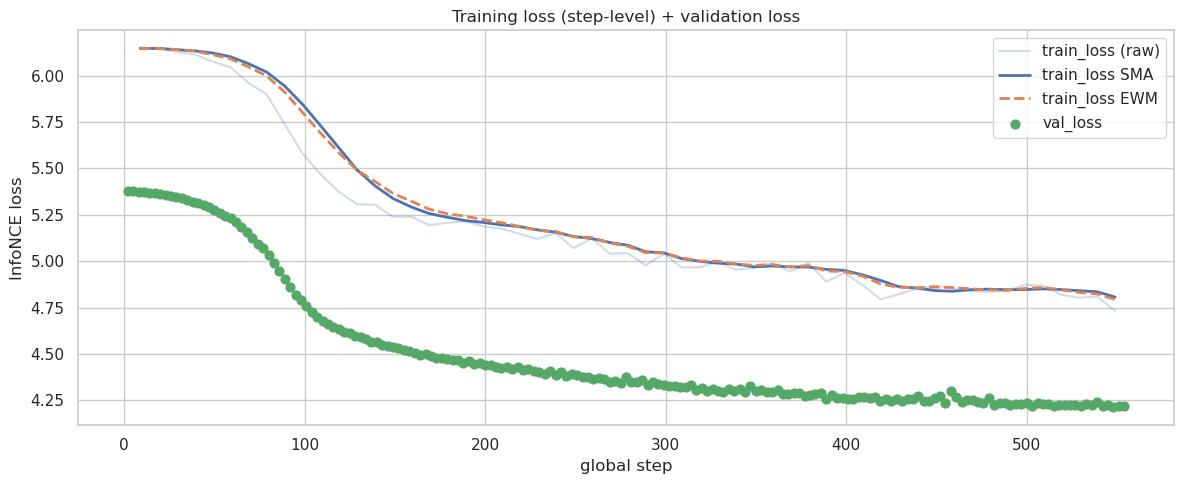

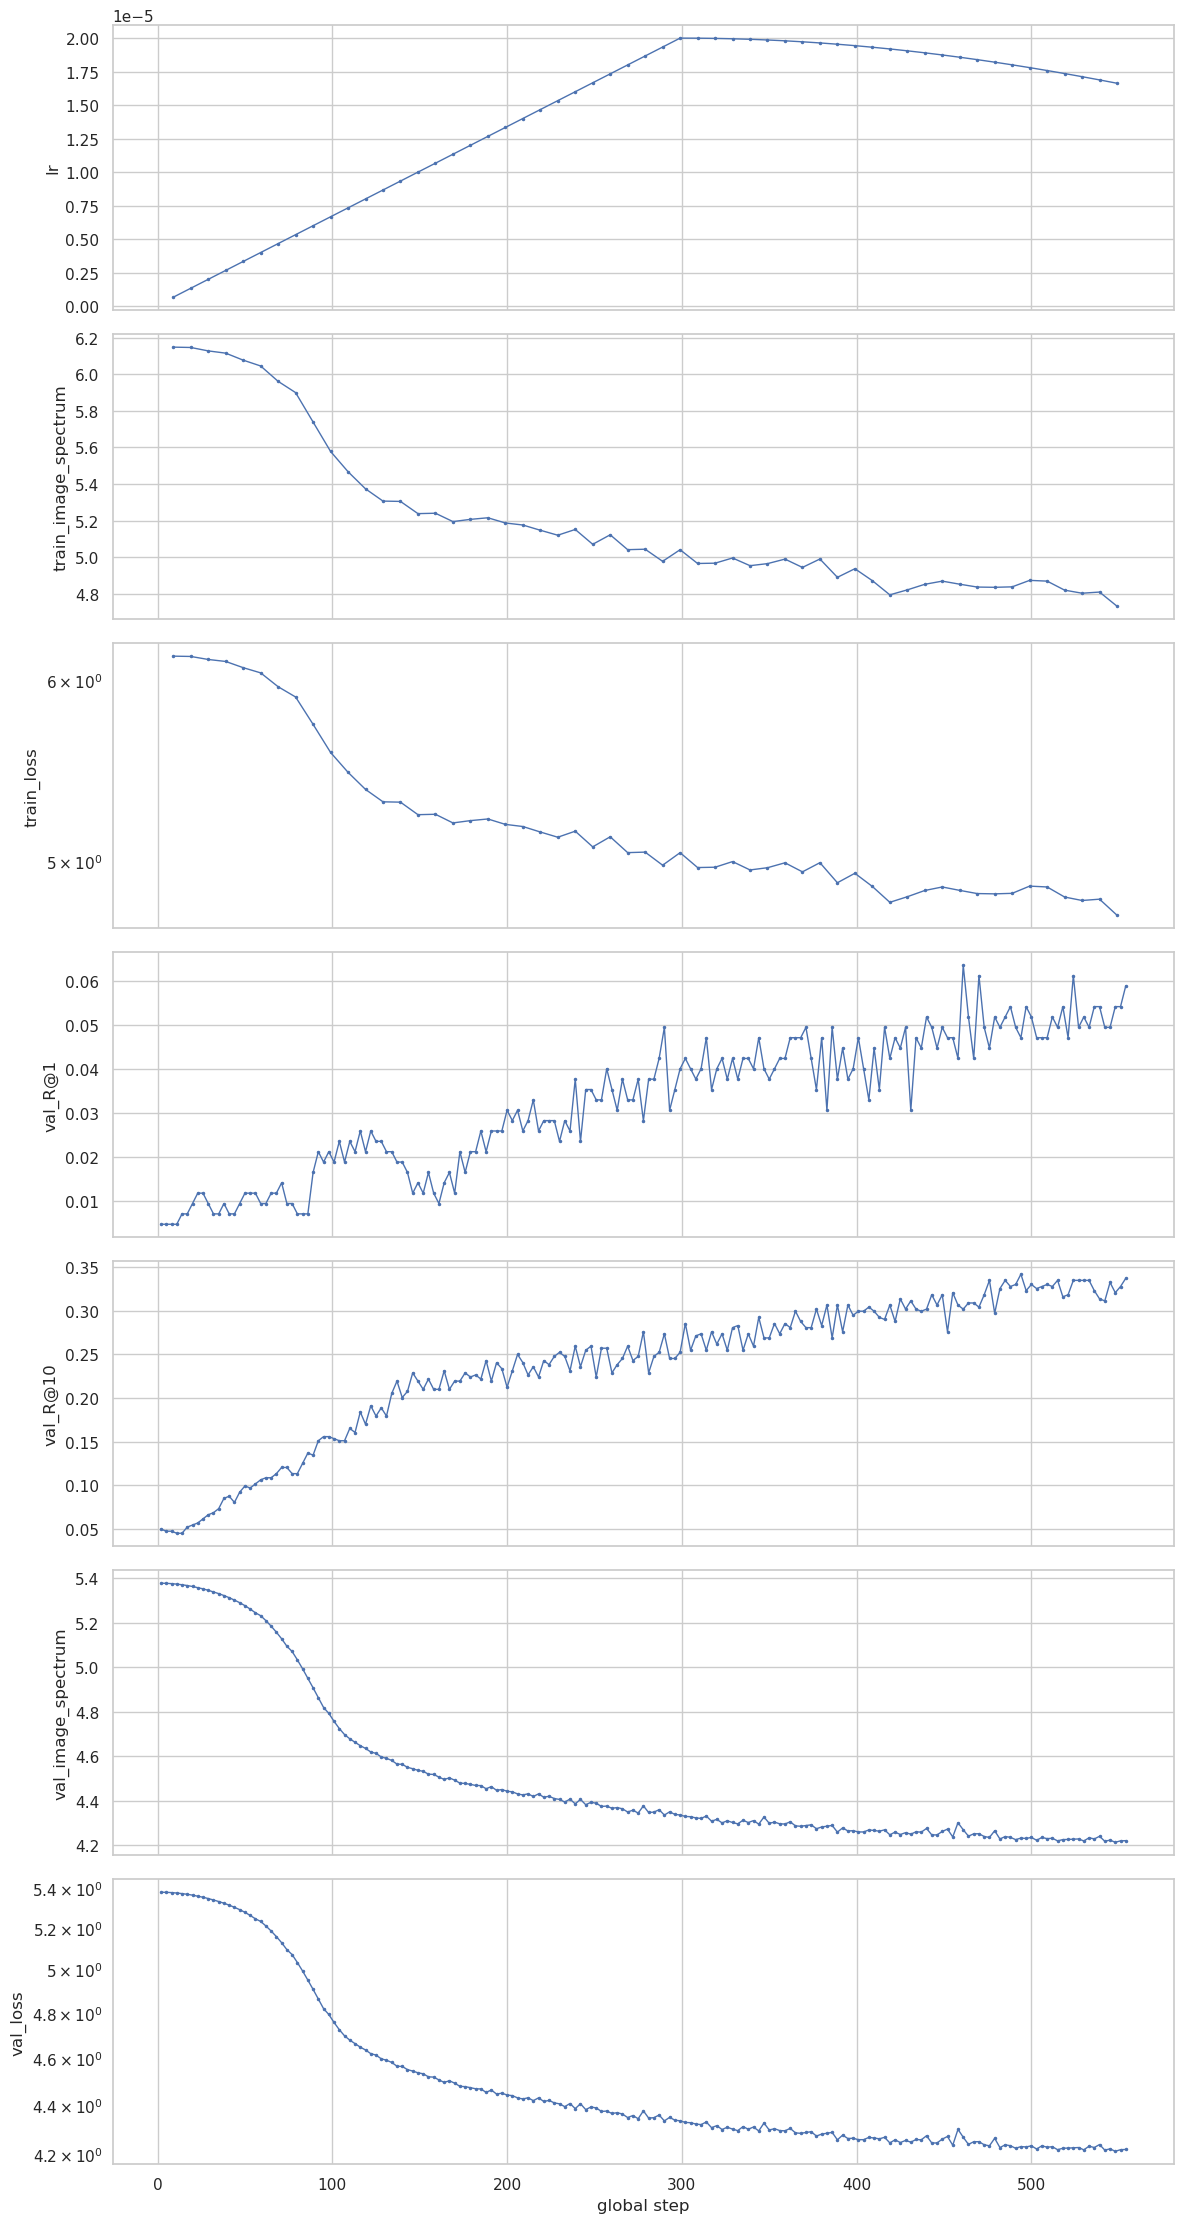

In [3]:
# Plot: step-level train_loss (raw + smoothed) with val_loss overlay
fig, ax = plt.subplots(figsize=(12, 5))

if not train_df.empty:
    ax.plot(train_df['step'], train_df['train_loss'], color='C0', alpha=0.25, label='train_loss (raw)')
    ax.plot(train_df['step'], train_df['train_loss_sma'], color='C0', linewidth=2, label='train_loss SMA')
    ax.plot(train_df['step'], train_df['train_loss_ewm'], color='C1', linestyle='--', linewidth=2, label='train_loss EWM')
if not val_df.empty:
    ax.scatter(val_df['step'], val_df['val_loss'], color='C2', s=40, zorder=5, label='val_loss')

# InfoNCE "no-information" baseline = ln(batch_size); val/last train batch may differ in size
ax.set_xlabel('global step'); ax.set_ylabel('InfoNCE loss')
ax.set_title('Training loss (step-level) + validation loss')
ax.legend(); plt.tight_layout(); plt.show()


# Plot: every numeric metric as its own subplot (lr, per-pair losses, etc.)
skip = {'epoch', 'step', 'train_loss_sma', 'train_loss_ewm'}
metric_cols = [c for c in raw.columns if c not in skip and raw[c].notna().any()]

n = len(metric_cols)
fig, axs = plt.subplots(n, 1, figsize=(12, 3.2 * n), sharex=True)
if n == 1:
    axs = [axs]
for ax, col in zip(axs, metric_cols):
    sub = train_df if (col in train_df.columns and train_df[col].notna().any()) else val_df
    s = sub[['step', col]].dropna()
    ax.plot(s['step'], s[col], marker='.', ms=3, lw=1)
    ax.set_ylabel(col)
    if 'loss' in col:
        ax.set_yscale('log')
axs[-1].set_xlabel('global step')
plt.tight_layout(); plt.show()